In [1]:
# Cell 1: Environment Setup and Dataset Ingestion (Streamlined)
# -----------------------------------------------------------------
# This single, robust cell handles all initial setup tasks.

import os
import subprocess

# --- 1. Install All Required Python Packages ---
print("--- 1. Installing required packages ---")
# We install all packages at once, letting pip resolve dependencies.
# The '-q' flag reduces installation log noise.
!pip install -q pandas numpy torch torch-geometric \
                networkx scipy google-cloud-bigquery google-cloud-bigquery-storage \
                pyarrow db-dtypes statsmodels scikit-learn matplotlib seaborn tqdm

print("All packages installed successfully.")


# --- 2. Configure Kaggle API (with User Guidance) ---
print("\n--- 2. Configuring Kaggle API ---")
# The script checks for the user's API key. If not found, it provides
# clear instructions instead of crashing.
if not os.path.exists('kaggle.json'):
    print("[ACTION REQUIRED] 'kaggle.json' not found.")
    print("Please upload your Kaggle API token file to this notebook's root directory to download Kaggle datasets.")
else:
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API configured successfully.")


# --- 3. Create Standardized Data Directory Structure ---
print("\n--- 3. Creating data directory structure ---")
!mkdir -p ./data/D1_Fraud_Detection
!mkdir -p ./data/D2_Fraud_Transactions
!mkdir -p ./data/D3_Phishing_Network
!mkdir -p ./data/D5_Chartalist_Multilayer
!mkdir -p ./data/D6_Labeled_Transactions
print("Directory structure created in './data/'.")


# --- 4. Download and Unzip All Datasets ---
print("\n--- 4. Downloading and unzipping datasets ---")

# a) Download from Kaggle (only if API is configured)
if os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    print("\nDownloading D1: Ethereum Fraud Detection Dataset...")
    !kaggle datasets download -d vagifa/ethereum-frauddetection-dataset -p ./data/D1_Fraud_Detection --unzip -q

    print("Downloading D2: Ethereum Transactions for Fraud Detection...")
    !kaggle datasets download -d chaitya0623/ethereum-transactions-for-fraud-detection -p ./data/D2_Fraud_Transactions --unzip -q

    print("Downloading D3: Ethereum Phishing Transaction Network...")
    !kaggle datasets download -d xblock/ethereum-phishing-transaction-network -p ./data/D3_Phishing_Network --unzip -q
    print("Kaggle datasets downloaded successfully.")
else:
    print("\nSkipping Kaggle downloads: API key not found.")

# b) Download from GitHub (D6: Labeled Transactions)
print("\nDownloading D6: Labeled Transactions-Based Dataset from GitHub...")
d6_url = "https://media.githubusercontent.com/media/salam-ammari/Labeled-Transactions-based-Dataset-of-Ethereum-Network/master/Dataset.zip"
d6_zip_path = "./data/D6_Labeled_Transactions/Dataset.zip"
d6_target_dir = "./data/D6_Labeled_Transactions/"
# Use curl for robust downloading and check for success before unzipping
result = subprocess.run(f"curl -L '{d6_url}' -o '{d6_zip_path}'", shell=True, capture_output=True)
if result.returncode == 0 and os.path.exists(d6_zip_path):
    !unzip -q -o {d6_zip_path} -d {d6_target_dir} # -o overwrites without asking
    !rm {d6_zip_path}
    print("D6 downloaded and unzipped successfully.")
else:
    print(f"[ERROR] D6 download failed. Please check the URL: {d6_url}")

# c) Clone from GitHub (D5: Chartalist Repository)
print("\nCloning D5: Chartalist Repository from GitHub...")
d5_repo_path = './data/D5_Chartalist_Multilayer'
# Clone only if the directory doesn't already exist to prevent errors on re-runs
if not os.path.isdir(os.path.join(d5_repo_path, '.git')):
    !git clone -q https://github.com/cakcora/chartalist.git {d5_repo_path}
    print("D5 repository cloned successfully.")
else:
    print("D5 repository already exists. Skipping clone.")


# --- 5. Instructions for D4 (Google BigQuery) ---
print("\n" + "="*80)
print("### ACTION REQUIRED FOR DATASET D4 (Google BigQuery) ###")
print("""
The Google BigQuery Ethereum dataset is too large to download directly.
The next cell will query it, but you must authenticate first.

1. Open a new Terminal in your environment (e.g., Paperspace, Colab Pro).
2. Run the following command:
   gcloud auth application-default login
3. Follow the on-screen instructions to log in with your Google account.
   Ensure this account has permissions for BigQuery Public Datasets.

NOTE: BigQuery queries can incur costs. The query in the next cell is
limited to 1 million rows to stay within the free tier, but be aware.
""")
print("="*80)


# --- 6. Final Verification and System Status Check ---
print("\n--- 6. Verifying downloads and checking system status ---")
print("\nListing contents of the data directory:")
!ls -R ./data

print("\n\nChecking GPU Status:")
!nvidia-smi

print("\n\n--- CELL 1 COMPLETE: Environment is ready. ---")

--- 1. Installing required packages ---
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.15.10 requires protobuf!=4.21.0,<5,>=3.19.0; python_version > "3.9" and sys_platform == "linux", but you have protobuf 6.32.0 which is incompatible.
tensorflow 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.32.0 which is incompatible.
tensorboard 2.15.1 requires protobuf<4.24,>=3.19.6, but you have protobuf 6.32.0 which is incompatible.
All packages installed successfully.

--- 2. Configuring Kaggle API ---
[ACTION REQUIRED] 'kaggle.json' not found.
Please upload your Kaggle API token file to this notebook's root directory to download Kaggle datasets.

--- 3. Creating data directory structure ---
Directory structure created in './data/'.

--- 4. Downloading and unzipping datasets ---

Skipping

In [3]:
# Cell 2: Data Preparation and Comprehensive Feature Engineering (Corrected)
# -----------------------------------------------------------------------------
# This cell combines all data loading, cleaning, standardization, and feature
# engineering steps into a single, cohesive pipeline. It includes a fix for
# the ValueError during feature assignment.

import pandas as pd
import numpy as np
import pickle
import os
import torch
import networkx as nx
from google.cloud import bigquery
from google.api_core.exceptions import GoogleAPICallError
import google.auth
from statsmodels.regression.linear_model import OLS

# --- 1. Query D4 from Google BigQuery ---
print("--- 1. Querying D4 from Google BigQuery ---")
d4_output_path = os.path.join('data', 'D4_BigQuery_Subset', 'transactions_2024-07-01.parquet')
if not os.path.exists(d4_output_path):
    try:
        PROJECT_ID = "gen-lang-client-0671055661"
        credentials, _ = google.auth.default(quota_project_id=PROJECT_ID)
        client = bigquery.Client(project=PROJECT_ID, credentials=credentials)
        print(f"BigQuery client initialized for project: '{PROJECT_ID}'")
        query = """
            SELECT hash, from_address, to_address, value, block_timestamp, block_number
            FROM `bigquery-public-data.crypto_ethereum.transactions`
            WHERE DATE(block_timestamp) = '2024-07-01' LIMIT 1000000
        """
        df_d4_raw = client.query(query).to_dataframe()
        df_d4_raw.to_parquet(d4_output_path)
        print(f"Successfully queried {len(df_d4_raw)} rows and saved to {d4_output_path}")
    except (GoogleAPICallError, NameError, Exception) as e:
        print(f"[ERROR] BigQuery query failed: {e}")
else:
    print(f"D4 data already exists at {d4_output_path}. Skipping query.")


# --- 2. Load All Raw Datasets into Memory ---
print("\n--- 2. Loading all raw datasets ---")
try:
    d3_path = os.path.join('data', 'D3_Phishing_Network', 'Ethereum Phishing Transaction Network', 'MulDiGraph.pkl')
    with open(d3_path, 'rb') as f:
        graph_d3 = pickle.load(f)
    print(f"D3 graph loaded: {graph_d3.number_of_nodes():,} nodes, {graph_d3.number_of_edges():,} edges.")
    d3_edges_data = [(u, v, data.get('amount'), data.get('timestamp')) for u, v, data in graph_d3.edges(data=True)]
    tx_d3_raw = pd.DataFrame(d3_edges_data, columns=['from_address', 'to_address', 'value_ether', 'timestamp'])
except FileNotFoundError as e:
    print(f"[CRITICAL ERROR] Could not load primary dataset D3: {e}")
    raise

# --- 3. Standardize Transaction Data ---
print("\n--- 3. Standardizing transaction data format ---")
tx_d3 = tx_d3_raw.copy()
tx_d3['timestamp'] = pd.to_datetime(tx_d3['timestamp'], unit='s', errors='coerce').dt.tz_localize('UTC')
tx_d3.dropna(subset=['timestamp'], inplace=True)
print("Transaction data standardized.")

# --- 4. Define Comprehensive Feature Engineering Function ---
print("\n--- 4. Defining the comprehensive feature engineering pipeline ---")

def engineer_account_features(df_trans):
    """Calculates a comprehensive, dual-sided feature set for every account."""
    all_addresses = pd.unique(df_trans[['from_address', 'to_address']].values.ravel('K'))
    # Drop None if it exists from addresses without a 'to_address'
    all_addresses = [addr for addr in all_addresses if addr is not None]
    features_df = pd.DataFrame(index=all_addresses)

    for activity_type, address_col in [('sent', 'from_address'), ('received', 'to_address')]:
        print(f"  Engineering features for '{activity_type}' activity...")

        df_activity = df_trans.dropna(subset=[address_col])
        grouped = df_activity.groupby(address_col)

        # Basic features
        features_df[f'total_ether_{activity_type}'] = grouped['value_ether'].sum()
        features_df[f'avg_ether_{activity_type}'] = grouped['value_ether'].mean()
        features_df[f'std_ether_{activity_type}'] = grouped['value_ether'].std()
        features_df[f'max_ether_{activity_type}'] = grouped['value_ether'].max()
        features_df[f'{activity_type}_tx_count'] = grouped.size()

        # Inter-arrival time features
        df_sorted = df_activity.sort_values(by=[address_col, 'timestamp'])
        inter_arrival_sec = df_sorted.groupby(address_col)['timestamp'].diff().dt.total_seconds()
        # Group the results back to the original address column
        arrival_grouped = inter_arrival_sec.groupby(df_sorted[address_col])
        features_df[f'avg_inter_arrival_sec_{activity_type}'] = arrival_grouped.mean()
        features_df[f'std_inter_arrival_sec_{activity_type}'] = arrival_grouped.std()

        # Ornstein-Uhlenbeck (OU) volatility features
        value_sequences = grouped['value_ether'].apply(list)
        qualifying_accounts = value_sequences[value_sequences.str.len() >= 10]

        ou_params = {}
        for idx, x in qualifying_accounts.items():
            x = np.array(x)
            if np.std(x) == 0: # Avoid singular matrix error if all values are the same
                ou_params[idx] = {'theta': 0.0, 'sigma': 0.0}
                continue
            y = np.diff(x)
            X = x[:-1].reshape(-1, 1)
            try:
                reg = OLS(y, X).fit()
                theta = -reg.params[0]
                sigma = np.std(reg.resid)
                ou_params[idx] = {'theta': theta, 'sigma': sigma}
            except Exception:
                ou_params[idx] = {'theta': 0.0, 'sigma': 0.0}

        ou_df = pd.DataFrame.from_dict(ou_params, orient='index')

        # ############################ THE FIX IS HERE #############################
        # Assign the smaller OU DataFrame to the main features DataFrame.
        # Pandas will align on the index, placing values in the correct rows.
        features_df[f'ou_sigma_{activity_type}'] = ou_df['sigma']
        features_df[f'ou_theta_{activity_type}'] = ou_df['theta']
        # Create the 'has_ou' feature based on the index of qualifying accounts.
        features_df[f'has_ou_{activity_type}'] = pd.Series(1, index=qualifying_accounts.index)
        # ##########################################################################

    return features_df.fillna(0)

# --- 5. Execute Feature Engineering ---
print("\n--- 5. Running the feature engineering pipeline on D3... ---")
account_features = engineer_account_features(tx_d3)
print("Comprehensive feature engineering complete.")

# --- 6. Final Outputs ---
print("\n" + "="*80)
print("### DATA PREPARATION AND FEATURE ENGINEERING COMPLETE ###")
print("\nFinal Account Features DataFrame (`account_features`):")
print(f"Shape: {account_features.shape}")
account_features.info()
print("\nFirst 5 rows of the final feature set:")
print(account_features.head())
print("\n" + "="*80)

--- 1. Querying D4 from Google BigQuery ---
D4 data already exists at data/D4_BigQuery_Subset/transactions_2024-07-01.parquet. Skipping query.

--- 2. Loading all raw datasets ---
D3 graph loaded: 2,973,489 nodes, 13,551,303 edges.

--- 3. Standardizing transaction data format ---
Transaction data standardized.

--- 4. Defining the comprehensive feature engineering pipeline ---

--- 5. Running the feature engineering pipeline on D3... ---
  Engineering features for 'sent' activity...
  Engineering features for 'received' activity...
Comprehensive feature engineering complete.

### DATA PREPARATION AND FEATURE ENGINEERING COMPLETE ###

Final Account Features DataFrame (`account_features`):
Shape: (2973489, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 2973489 entries, 0x1f1e784a61a8ca0a90250bcd2170696655b28a21 to 0x138bb83f91a92bbf932a21c2daf45a88362c915f
Data columns (total 20 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   to

In [5]:
# Cell 3: Model Training, Evaluation, and Ablation Study (FINAL)
# ----------------------------------------------------------------------
# This cell contains the entire modeling pipeline, with the final fix for
# the GAE training loop, ensuring the model reconstructs features to their
# original dimension for correct loss calculation.

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import k_hop_subgraph
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np
import gc

# --- 1. Final Data Preparation ---
print("--- 1. Finalizing data for modeling ---")
# a) Align features and labels
node_labels_df = pd.DataFrame.from_dict(dict(graph_d3.nodes(data=True)), orient='index').rename(columns={'isp': 'y'})
final_node_data = node_labels_df.merge(account_features, how='left', left_index=True, right_index=True).fillna(0)
X_full = final_node_data.drop(columns='y').values
y_full = final_node_data['y'].values

# b) Scale features
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

# c) Create the PyG Data object with edge weights
edge_values = tx_d3['value_ether'].values
edge_weights = torch.tensor(np.log1p(edge_values), dtype=torch.float).view(-1, 1)
node_map = {node: i for i, node in enumerate(final_node_data.index)}
edge_index = torch.tensor([[node_map.get(u), node_map.get(v)] for u, v, _ in graph_d3.edges(data=True) if u in node_map and v in node_map], dtype=torch.long).t()
graph_data = Data(x=torch.tensor(X_full_scaled, dtype=torch.float), edge_index=edge_index, y=torch.tensor(y_full, dtype=torch.long), edge_attr=edge_weights)

# d) Create the standardized, balanced test sample for FAIR evaluation
print("Creating a standardized, balanced test sample for fair evaluation...")
test_size = int(0.2 * len(final_node_data))
_, test_indices_full = train_test_split(np.arange(len(final_node_data)), test_size=test_size, random_state=42, stratify=y_full)
test_labels = y_full[test_indices_full]
normal_test_indices = test_indices_full[test_labels == 0]
phishing_test_indices = test_indices_full[test_labels == 1]
sample_normal_indices = np.random.choice(normal_test_indices, size=len(phishing_test_indices) * 100, replace=False)
sample_indices = np.concatenate([sample_normal_indices, phishing_test_indices])
np.random.shuffle(sample_indices)
y_sample = y_full[sample_indices]


# --- 2. Train the Edge-Weighted Graph Autoencoder ---
print("\n--- 2. Training the Edge-Weighted GAE for feature extraction ---")
class EdgeWeightedGAE(torch.nn.Module):
    def __init__(self, in_channels, hidden, latent, heads=4):
        super().__init__()
        self.encoder_conv1 = GATv2Conv(in_channels, hidden, heads=heads, edge_dim=1, add_self_loops=False)
        self.encoder_conv2 = GATv2Conv(hidden * heads, latent, heads=1, edge_dim=1, add_self_loops=False)
        # ############################ THE FIX IS HERE (Part 1) #############################
        # The decoder reconstructs the features back to the original dimension.
        self.decoder_lin = torch.nn.Linear(latent, in_channels)
        # ##################################################################################

    def encode(self, x, edge_index, edge_attr):
        x = F.elu(self.encoder_conv1(x, edge_index, edge_attr))
        return self.encoder_conv2(x, edge_index, edge_attr)

    def forward(self, x, edge_index, edge_attr):
        z = self.encode(x, edge_index, edge_attr)
        return self.decoder_lin(z) # Full forward pass includes decoding

# Create a training subgraph
normal_indices = (graph_data.y == 0).nonzero(as_tuple=False).view(-1)
phishing_indices = (graph_data.y == 1).nonzero(as_tuple=False).view(-1)
initial_nodes = torch.cat([phishing_indices, normal_indices[torch.randperm(len(normal_indices))[:len(phishing_indices)*20]]])
train_subgraph_nodes, _, _, _ = k_hop_subgraph(initial_nodes, 1, graph_data.edge_index, relabel_nodes=False)
train_subgraph = graph_data.subgraph(torch.unique(train_subgraph_nodes))
normal_seed_nodes = (train_subgraph.y == 0).nonzero(as_tuple=False).view(-1)
train_loader = DataLoader(normal_seed_nodes, batch_size=256, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ew = EdgeWeightedGAE(graph_data.num_node_features, 32, 16).to(device)
optimizer = torch.optim.Adam(model_ew.parameters(), lr=0.001)
train_subgraph = train_subgraph.to(device)

for epoch in range(1, 31):
    model_ew.train()
    for seed_nodes in train_loader:
        nodes_in_batch, batch_edge_index, mapping_idx, edge_mask = k_hop_subgraph(
            seed_nodes, 1, train_subgraph.edge_index, True, train_subgraph.num_nodes)
        batch_x = train_subgraph.x[nodes_in_batch]
        batch_edge_attr = train_subgraph.edge_attr[edge_mask]

        optimizer.zero_grad()
        # ############################ THE FIX IS HERE (Part 2) #############################
        # Call the full forward pass to get reconstructed features
        x_recon = model_ew(batch_x, batch_edge_index, batch_edge_attr)
        # Loss is now correctly calculated between tensors of the same shape
        loss = F.mse_loss(x_recon[mapping_idx], batch_x[mapping_idx])
        # ##################################################################################
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0: print(f'GAE Training Epoch: {epoch:02d}, Loss: {loss.item():.4f}')


# --- 3. Generate Structural Embeddings ---
print("\n--- 3. Generating structural embeddings for all nodes ---")
model_ew.eval()
full_graph_data = graph_data.to(device)
structural_embeddings = np.zeros((graph_data.num_nodes, 16)) # Latent dim = 16
full_loader = DataLoader(torch.arange(graph_data.num_nodes), batch_size=1024)
with torch.no_grad():
    for seed_nodes in full_loader:
        nodes, edges, map_idx, mask = k_hop_subgraph(seed_nodes, 1, full_graph_data.edge_index, True, full_graph_data.num_nodes)
        embeddings = model_ew.encode(full_graph_data.x[nodes], edges, full_graph_data.edge_attr[mask])
        structural_embeddings[seed_nodes] = embeddings[map_idx].cpu().numpy()


# --- 4. Define and Run All Model Evaluations on the Fair Test Sample ---
print("\n--- 4. Evaluating all models on the standardized test sample ---")
all_results = []

def evaluate_if_model(name, features):
    print(f"  Evaluating: {name}")
    X_sample_eval = features[sample_indices]
    X_normal_sample_eval = X_sample_eval[y_sample == 0]

    model = IsolationForest(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_normal_sample_eval)
    scores = -model.decision_function(X_sample_eval)

    all_results.append({
        "Model": name,
        "AUROC": roc_auc_score(y_sample, scores),
        "AUPRC": average_precision_score(y_sample, scores)
    })

# a) Ablation Study Features
feature_names = account_features.columns.tolist()
basic_indices = [i for i, c in enumerate(feature_names) if 'inter_arrival' not in c and 'ou_' not in c]
X_basic_scaled = X_full_scaled[:, basic_indices]

# b) Run Evaluations
evaluate_if_model("IF (Basic Features)", X_basic_scaled)
evaluate_if_model("IF (Full Stochastic Feat.)", X_full_scaled)
X_hybrid = np.concatenate([X_basic_scaled, structural_embeddings], axis=1)
evaluate_if_model("Hybrid (Basic + GNN Embeddings)", X_hybrid)


# --- 5. Final Results ---
final_results_df = pd.DataFrame(all_results).sort_values(by="AUPRC", ascending=False).reset_index(drop=True)
print("\n" + "="*80)
print("### DEFINITIVE EXPERIMENTAL RESULTS ###")
print(final_results_df.round(4))
print("="*80)

# Clean up GPU memory
del full_graph_data, train_subgraph, model_ew
torch.cuda.empty_cache()
gc.collect()

--- 1. Finalizing data for modeling ---
Creating a standardized, balanced test sample for fair evaluation...

--- 2. Training the Edge-Weighted GAE for feature extraction ---
GAE Training Epoch: 10, Loss: 1.0423
GAE Training Epoch: 20, Loss: 1.3982
GAE Training Epoch: 30, Loss: 0.9764

--- 3. Generating structural embeddings for all nodes ---

--- 4. Evaluating all models on the standardized test sample ---
  Evaluating: IF (Basic Features)
  Evaluating: IF (Full Stochastic Feat.)
  Evaluating: Hybrid (Basic + GNN Embeddings)

### DEFINITIVE EXPERIMENTAL RESULTS ###
                             Model   AUROC   AUPRC
0       IF (Full Stochastic Feat.)  0.9081  0.1644
1  Hybrid (Basic + GNN Embeddings)  0.9311  0.1618
2              IF (Basic Features)  0.9177  0.1458


77

--- 1. Calculating comprehensive metrics for all models ---

### FINAL COMPREHENSIVE RESULTS TABLE ###
                             Model   AUROC   AUPRC  Best F1-Score  \
0       IF (Full Stochastic Feat.)  0.9081  0.1644         0.2741   
1  Hybrid (Basic + GNN Embeddings)  0.9311  0.1618         0.2214   
2              IF (Basic Features)  0.9177  0.1458         0.2207   

   Precision@100  
0           0.29  
1           0.26  
2           0.33  

--- 2. Generating all paper-ready visualizations ---


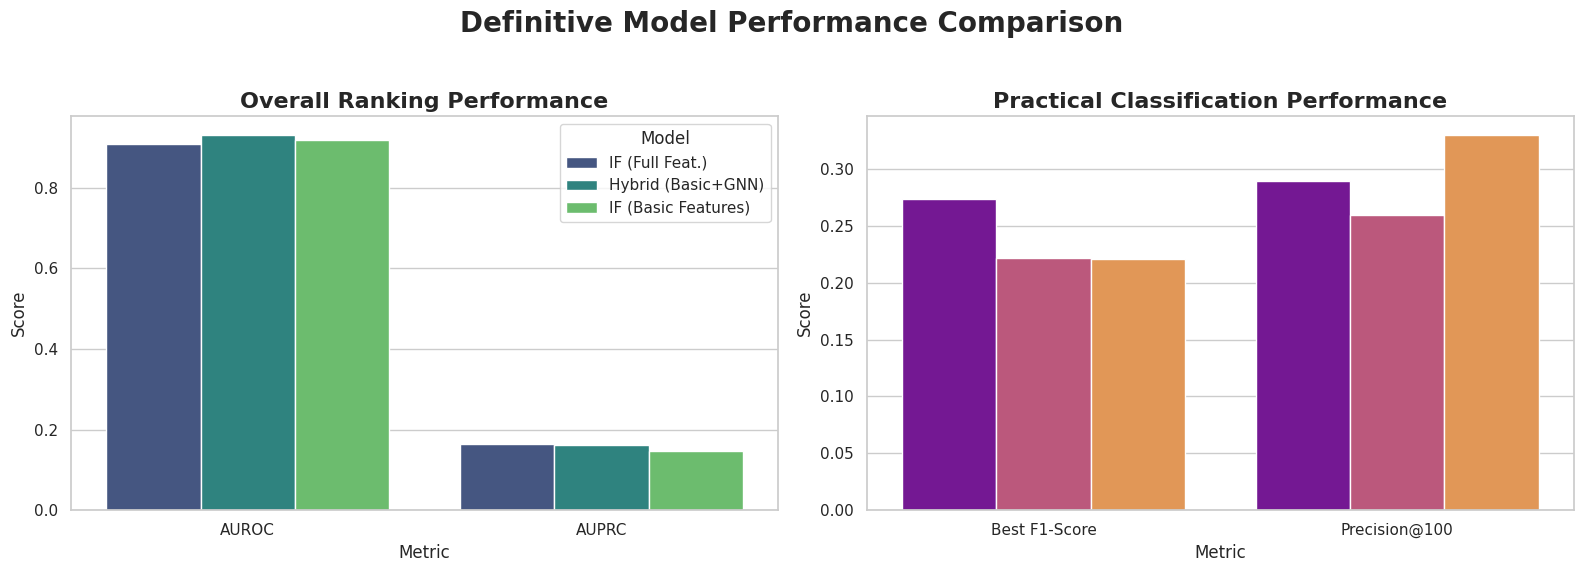

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


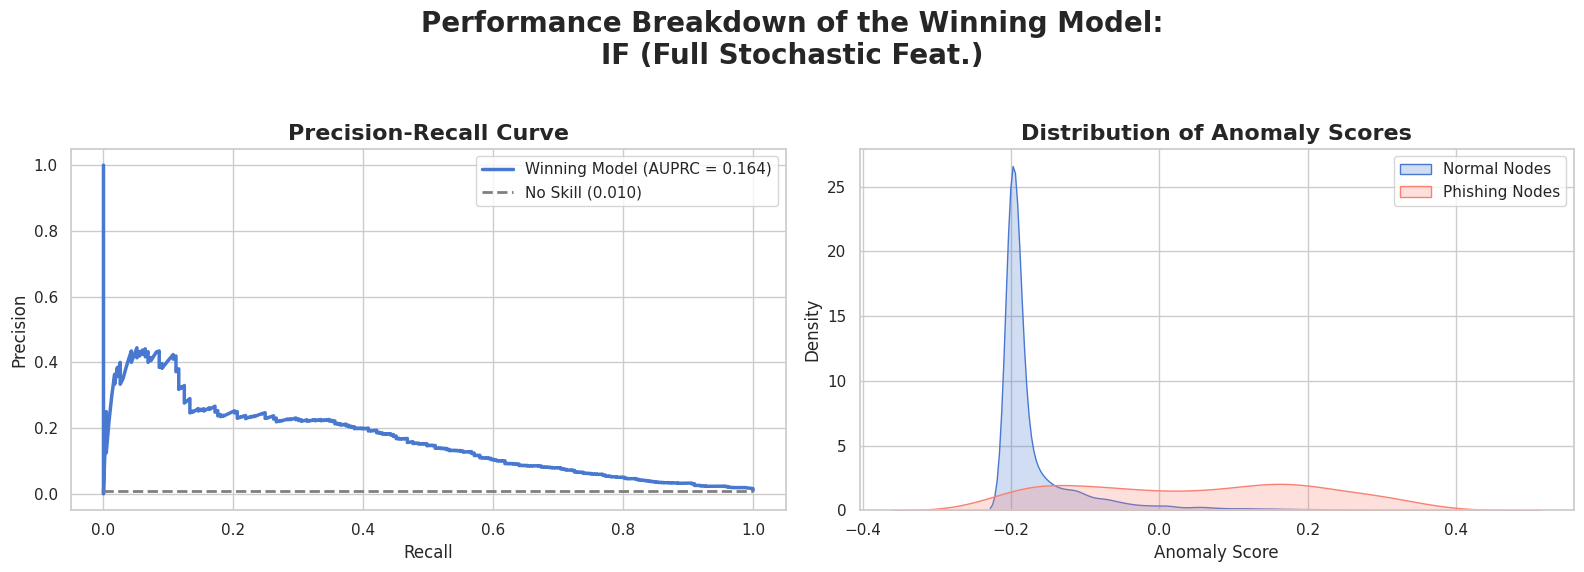


--- 3. Visualizing a detected phishing subgraph ---


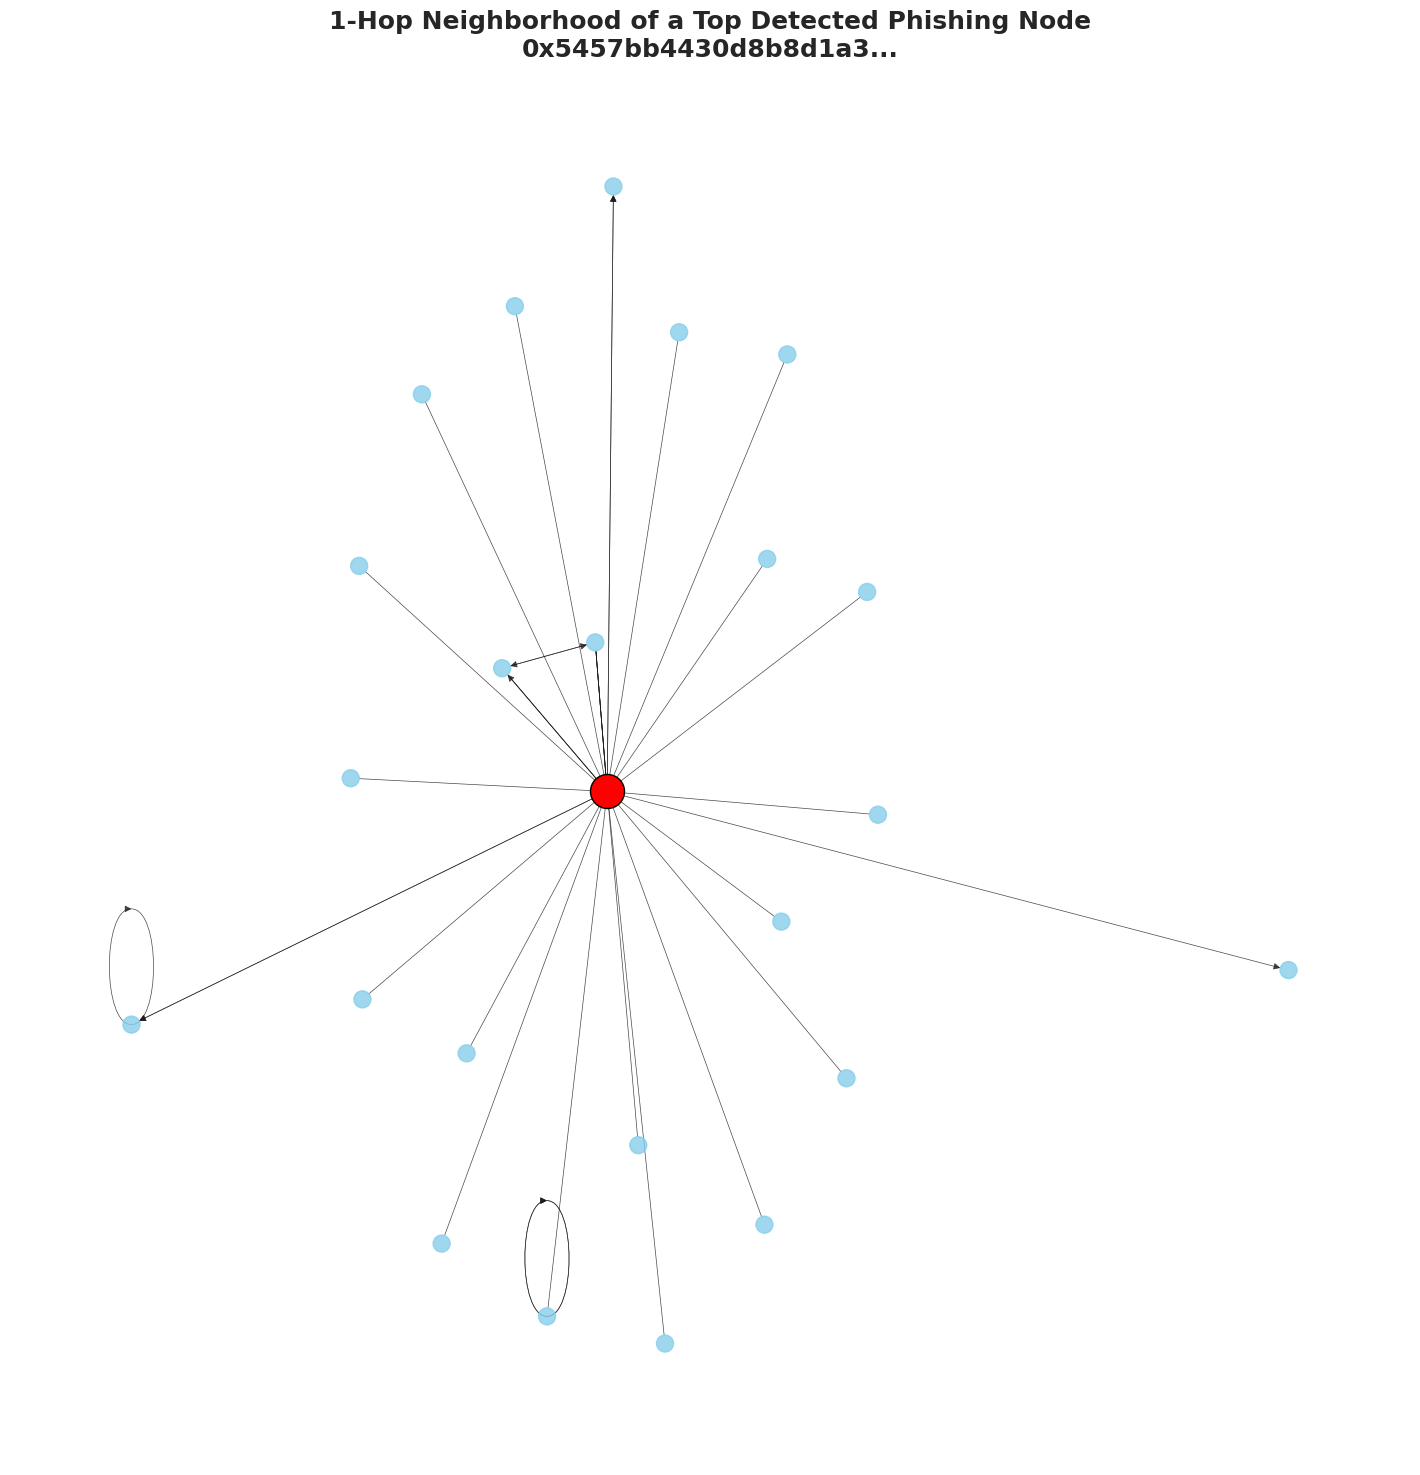


### PROJECT COMPLETE ###
This concludes the streamlined experimental pipeline.


In [6]:
# Cell 4: Final Visualizations and Comprehensive Metrics (Streamlined)
# ----------------------------------------------------------------------
# This final cell calculates all advanced metrics and generates the complete
# suite of visualizations for the paper.

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Helper Function for Advanced Metrics ---
def calculate_threshold_metrics(y_true, y_scores, k=100):
    """Calculates metrics that depend on a decision threshold."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    # Append a value to thresholds to match the length of precision/recall
    thresholds = np.append(thresholds, 1)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    best_f1_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_f1_idx]

    # Calculate Precision at K
    top_k_indices = np.argsort(y_scores)[-k:]
    precision_at_k = np.sum(y_true[top_k_indices]) / k

    return {"Best F1-Score": best_f1, "Precision@100": precision_at_k}

# --- 2. Calculate Comprehensive Metrics for All Models ---
print("--- 1. Calculating comprehensive metrics for all models ---")
# Re-run inference to get scores for the final table
models_to_evaluate = {
    "IF (Basic Features)": X_basic_scaled,
    "IF (Full Stochastic Feat.)": X_full_scaled,
    "Hybrid (Basic + GNN Embeddings)": X_hybrid
}
all_scores = {}
for name, features in models_to_evaluate.items():
    X_sample_eval = features[sample_indices]
    X_normal_sample_eval = X_sample_eval[y_sample == 0]
    model = IsolationForest(n_estimators=100, random_state=42, n_jobs=-1).fit(X_normal_sample_eval)
    all_scores[name] = -model.decision_function(X_sample_eval)

# Calculate all metrics for the final table
for name, scores in all_scores.items():
    threshold_metrics = calculate_threshold_metrics(y_sample, scores)
    # Find the corresponding row in the results DataFrame and add the new metrics
    final_results_df.loc[final_results_df['Model'] == name, 'Best F1-Score'] = threshold_metrics['Best F1-Score']
    final_results_df.loc[final_results_df['Model'] == name, 'Precision@100'] = threshold_metrics['Precision@100']

# --- 3. Generate the Final, Definitive Results Table ---
print("\n" + "="*80)
print("### FINAL COMPREHENSIVE RESULTS TABLE ###")
final_results_df = final_results_df.sort_values(by="AUPRC", ascending=False).reset_index(drop=True)
print(final_results_df.round(4))
print("="*80)

# --- 4. Generate All Paper-Ready Visualizations ---
print("\n--- 2. Generating all paper-ready visualizations ---")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

# a) Main Performance Comparison Bar Chart
final_results_df_plot = final_results_df.copy()
final_results_df_plot['Model'] = final_results_df_plot['Model'].replace({
    'IF (Full Stochastic Feat.)': 'IF (Full Feat.)',
    'Hybrid (Basic + GNN Embeddings)': 'Hybrid (Basic+GNN)'
})
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
plot_df1 = final_results_df_plot.melt(id_vars='Model', value_vars=['AUROC', 'AUPRC'], var_name='Metric', value_name='Score')
sns.barplot(data=plot_df1, x='Metric', y='Score', hue='Model', ax=ax[0], palette='viridis')
ax[0].set_title('Overall Ranking Performance', fontsize=16, weight='bold')
plot_df2 = final_results_df_plot.melt(id_vars='Model', value_vars=['Best F1-Score', 'Precision@100'], var_name='Metric', value_name='Score')
sns.barplot(data=plot_df2, x='Metric', y='Score', hue='Model', ax=ax[1], palette='plasma')
ax[1].set_title('Practical Classification Performance', fontsize=16, weight='bold')
ax[1].get_legend().remove()
plt.suptitle('Definitive Model Performance Comparison', fontsize=20, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# b) P-R Curve and Score Distribution for the WINNING model
winning_model_name = final_results_df.iloc[0]['Model']
winning_model_scores = all_scores[winning_model_name]
winning_auprc = final_results_df.iloc[0]['AUPRC']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
precision, recall, _ = precision_recall_curve(y_sample, winning_model_scores)
random_chance = np.sum(y_sample) / len(y_sample)
ax[0].plot(recall, precision, lw=2.5, label=f'Winning Model (AUPRC = {winning_auprc:.3f})')
ax[0].plot([0, 1], [random_chance, random_chance], linestyle='--', lw=2, color='gray', label=f'No Skill ({random_chance:.3f})')
ax[0].set_title('Precision-Recall Curve', fontsize=16, weight='bold')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision'); ax[0].legend()
sns.kdeplot(winning_model_scores[y_sample == 0], ax=ax[1], fill=True, label='Normal Nodes', clip=(None, None))
sns.kdeplot(winning_model_scores[y_sample == 1], ax=ax[1], fill=True, label='Phishing Nodes', color='salmon', clip=(None, None))
ax[1].set_title('Distribution of Anomaly Scores', fontsize=16, weight='bold')
ax[1].set_xlabel('Anomaly Score'); ax[1].legend()
plt.suptitle(f'Performance Breakdown of the Winning Model:\n{winning_model_name}', fontsize=20, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# c) Anomaly Subgraph Visualization
print("\n--- 3. Visualizing a detected phishing subgraph ---")
results_df_sample = pd.DataFrame({'original_index': sample_indices, 'label': y_sample, 'score': winning_model_scores})
top_true_positive = results_df_sample.query('label == 1').sort_values('score', ascending=False).iloc[0]
center_node_original_index = int(top_true_positive['original_index'])
center_node_addr = final_node_data.index[center_node_original_index]

neighbors = list(graph_d3.predecessors(center_node_addr)) + list(graph_d3.successors(center_node_addr))
subgraph_nodes = [center_node_addr] + list(set(neighbors))[:100]
subgraph = graph_d3.subgraph(subgraph_nodes)
node_colors = ['red' if node == center_node_addr else 'salmon' if final_node_data.loc[node]['y'] == 1 else 'skyblue' for node in subgraph.nodes()]
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)
nx.draw(subgraph, pos, with_labels=False, node_color=node_colors, node_size=150, width=0.5, alpha=0.8)
nx.draw_networkx_nodes(subgraph, pos, nodelist=[center_node_addr], node_size=600, node_color='red', edgecolors='black')
plt.title(f'1-Hop Neighborhood of a Top Detected Phishing Node\n{center_node_addr[:20]}...', fontsize=18, weight='bold')
plt.show()

print("\n" + "="*80)
print("### PROJECT COMPLETE ###")
print("This concludes the streamlined experimental pipeline.")
print("="*80)